# Analyse des topics avec LDA

LDA (Latent Dirichlet Allocation)
Modello probabilistico che rappresenta ogni documento come una distribuzione di topic
e ogni topic come una distribuzione di parole. È uno dei metodi più classici per topic modelling.

In [1]:
import os
import re
from tqdm import tqdm

import functionwordsets as fw

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
# stopwords
fr = fw.load()
custom_stopwords = [feat.strip() for feat in fr.all]

In [ ]:
def load_corpus_with_years(folder_path):
    documents = {}
    years = {}
    
    for file in os.listdir(folder_path):
        if file.endswith(".txt"):
            
            # Estrazione anno
            year_match = re.match(r"(\d{4})", file)
            if not year_match:
                continue
            
            year = int(year_match.group(1))
            
            # Lettura file
            with open(os.path.join(folder_path, file), "r", encoding="utf-8") as f:
                text = f.read()
            
            documents[file] = text
            years[file] = year
    
    return documents, years

corpus_path = "Corpus_txt"
docs, years = load_corpus_with_years(corpus_path)

In [4]:
# carico il file txt con le NE e creo una lista
ne = "characters.txt"
with open(ne, "r", encoding="utf-8") as f:
    named_entities = f.read().splitlines()
named_entities[:10]  # Visualizza le prime 10 named entities

['étienne',
 "l' ami étienne",
 'martineau',
 'monsieur étienne gilbert',
 'françois',
 'ruysdaël',
 'mister newall',
 'étienne gilbert',
 'pierre',
 'pauvre étienne']

In [5]:
# lemmatizzazione
import spacy

nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

In [6]:
from tqdm import tqdm

def preprocess_lemmatized(text, proper_nouns_set, nlp):
    doc = nlp(text)
    
    words = []
    entities = []
    
    for token in doc:
        lemma = token.lemma_.lower()
        
        # salta roba inutile
        if not token.is_alpha:
            continue
        
        # separa entità (basato su lista salvata)
        if lemma in named_entities:
            entities.append(lemma)
            continue
        
        # filtri per topic modelling
        if len(lemma) > 2 and token.pos_ in ["NOUN", "ADJ", "VERB"]:
            words.append(lemma)
    
    return " ".join(words), entities

In [7]:
# chunking
def split_text(text, max_chars=50000):
    return [
        text[i:i+max_chars]
        for i in range(0, len(text), max_chars)
    ]

In [8]:
docs_clean = []
docs_entities = []
names = []

for filename, text in tqdm(docs.items()):
    
    chunks = split_text(text, max_chars=50000)
    
    words_doc = []
    entities_doc = []
    
    for doc in nlp.pipe(chunks, batch_size=8, n_process=4):
        
        for token in doc:
            lemma = token.lemma_.lower()
            
            if not token.is_alpha:
                continue
            
            if lemma in named_entities:
                entities_doc.append(lemma)
                continue
            
            if len(lemma) > 2 and token.pos_ in ["NOUN", "ADJ", "VERB"]:
                words_doc.append(lemma)
    
    docs_clean.append(" ".join(words_doc))
    docs_entities.append(entities_doc)
    names.append(filename)

100%|██████████| 124/124 [31:48<00:00, 15.39s/it]


In [9]:
# per salvare il risultato della lemmatizzazione
import pickle

with open("preprocessed_data_lda-lemma-ne.pkl", "wb") as f:
    pickle.dump({
        "docs_clean": docs_clean,
        "docs_entities": docs_entities,
        "names": names
    }, f)

In [11]:
# per caricare il risultato della lemmatizzazione e proseguire
import pickle

with open("preprocessed_data_lda-lemma-ne.pkl", "rb") as f:
    data = pickle.load(f)

docs_clean = data["docs_clean"]
docs_entities = data["docs_entities"]
names = data["names"]

In [12]:
# vectorizer
vectorizer = CountVectorizer(
    stop_words=custom_stopwords,
    ngram_range=(1,1),
    min_df=2,
    max_df=0.7
)

X = vectorizer.fit_transform(docs_clean)

/Users/deniseatzori/miniconda3/envs/Tesi/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abord', 'afin', 'attendu', 'aujourd', 'auprès', 'cas', 'champ', 'chose', 'ci', 'compte', 'condition', 'contraire', 'coup', 'dernier', 'dire', 'doute', 'effet', 'emblée', 'ensemble', 'fait', 'façon', 'fur', 'général', 'hui', 'instant', 'jusqu', 'lieu', 'loin', 'matin', 'mesure', 'mien', 'mienne', 'miennes', 'miens', 'moment', 'même', 'nouveau', 'nôtre', 'nôtres', 'où', 'parce', 'part', 'particulier', 'peine', 'pourvu', 'premier', 'propos', 'près', 'qu', 'quant', 'quelqu', 'réalité', 'récemment', 'sien', 'sienne', 'siennes', 'siens', 'soir', 'somme', 'sorte', 'suite', 'sûr', 'tandis', 'temps', 'tien', 'tienne', 'tiennes', 'tiens', 'travers', 'unes', 'uns', 'vis', 'vrai', 'vu', 'vôtre', 'vôtres'] not in stop_words.
  warnings.warn(


In [13]:
# LDA
lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42
)

lda.fit(X)

,n_components,10
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [ ]:
# # Tuning hyperparameters (random search)

# import random
# import numpy as np

# # =========================
# # 1. SPAZIO PARAMETRI
# # =========================
# param_dist = {
#     "n_components": [5, 10, 15, 20],
#     "doc_topic_prior": [None, 0.1, 0.5, 1.0],
#     "topic_word_prior": [None, 0.1, 0.5, 1.0],
#     "learning_decay": [0.5, 0.7, 0.9]
# }

# # =========================
# # 2. RANDOM SEARCH
# # =========================
# n_iter = 10  # numero iterazioni (puoi aumentare)

# results = []

# for i in range(n_iter):
#     params = {
#         key: random.choice(values)
#         for key, values in param_dist.items()
#     }
    
#     print(f"\n🔍 Iterazione {i+1}")
#     print(params)
    
#     lda = LatentDirichletAllocation(
#         **params,
#         random_state=42,
#         learning_method="batch"  # più stabile
#     )
    
#     lda.fit(X)
    
#     # =========================
#     # 3. METRICA: PERPLEXITY
#     # =========================
#     perplexity = lda.perplexity(X)
    
#     print(f"Perplexity: {perplexity}")
    
#     results.append({
#         "params": params,
#         "perplexity": perplexity,
#         "model": lda
#     })

# # =========================
# # 4. MIGLIOR MODELLO
# # =========================
# best = min(results, key=lambda x: x["perplexity"])

# print("\n🏆 MIGLIOR MODELLO:")
# print(best["params"])
# print("Perplexity:", best["perplexity"])

# best_lda = best["model"]


🔍 Iterazione 1
{'n_components': 5, 'doc_topic_prior': 1.0, 'topic_word_prior': 1.0, 'learning_decay': 0.7}
Perplexity: 7571.674035995638

🔍 Iterazione 2
{'n_components': 5, 'doc_topic_prior': 0.1, 'topic_word_prior': 0.1, 'learning_decay': 0.7}
Perplexity: 7843.759004870293

🔍 Iterazione 3
{'n_components': 20, 'doc_topic_prior': 0.5, 'topic_word_prior': 1.0, 'learning_decay': 0.9}
Perplexity: 7520.783474172229

🔍 Iterazione 4
{'n_components': 20, 'doc_topic_prior': 1.0, 'topic_word_prior': None, 'learning_decay': 0.9}
Perplexity: 8296.237503095826

🔍 Iterazione 5
{'n_components': 15, 'doc_topic_prior': None, 'topic_word_prior': 1.0, 'learning_decay': 0.5}
Perplexity: 7444.782645740241

🔍 Iterazione 6
{'n_components': 5, 'doc_topic_prior': None, 'topic_word_prior': None, 'learning_decay': 0.7}
Perplexity: 7626.683211669915

🔍 Iterazione 7
{'n_components': 10, 'doc_topic_prior': None, 'topic_word_prior': None, 'learning_decay': 0.7}
Perplexity: 7592.528147381681

🔍 Iterazione 8
{'n_comp

In [14]:
# topic
def print_topics(model, feature_names, n_top_words=40):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic {idx}:")
        print([feature_names[i] for i in topic.argsort()[-n_top_words:]])

feature_names = vectorizer.get_feature_names_out()
print_topics(lda, feature_names)


Topic 0:
['tas', 'fée', 'répondi', 'sourcil', 'page', 'représentation', 'lampe', 'grimace', 'assiette', 'café', 'malle', 'note', 'bonnet', 'soulier', 'demoiselle', 'ridicule', 'piano', 'mlle', 'journal', 'poupée', 'bateau', 'aveugle', 'billet', 'magister', 'hôtel', 'docteur', 'tuteur', 'public', 'professeur', 'pension', 'mademoisell', 'lycée', 'neige', 'vache', 'capitaine', 'chanoinesse', 'juge', 'classe', 'curé', 'tante']

Topic 1:
['bonnet', 'ouvrier', 'montagne', 'pension', 'constater', 'épouser', 'illusion', 'bal', 'paresseux', 'intime', 'serviteur', 'parc', 'officier', 'orphelin', 'propriétaire', 'agnè', 'héritier', 'veuve', 'hôte', 'compagne', 'invitation', 'marraine', 'apprécier', 'classe', 'hôtel', 'notaire', 'demoiselle', 'professeur', 'neveu', 'écolier', 'chéri', 'vacance', 'capitaine', 'docteur', 'nièce', 'colonel', 'vieillard', 'mademoisell', 'mlle', 'tante']

Topic 2:
['lac', 'âne', 'pourpoint', 'boa', 'sable', 'puits', 'cabinet', 'vaniteux', 'mille', 'épine', 'apprivoise

# Salvo i topic con le parole associate per ogni romanzo

In [15]:
def get_topic_words(model, feature_names, n_top_words=20):
    topic_words = {}
    
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[-n_top_words:][::-1]]
        topic_words[topic_idx] = top_words
    
    return topic_words

feature_names = vectorizer.get_feature_names_out()
topic_words_dict = get_topic_words(lda, feature_names, n_top_words=20)

In [16]:
doc_topic_dist = lda.transform(X)

In [17]:
doc_topic_dist[0]
# → [0.1, 0.7, 0.05, ...]

array([2.94354407e-05, 9.99735075e-01, 2.94321117e-05, 2.94355073e-05,
       2.94336842e-05, 2.94359441e-05, 2.94399912e-05, 2.94374096e-05,
       2.94372118e-05, 2.94378254e-05])

In [18]:
import numpy as np

doc_topics = np.argmax(doc_topic_dist, axis=1)

In [19]:
for i, dist in enumerate(doc_topic_dist):
    top_topic = np.argmax(dist)
    prob = dist[top_topic]
    
    print(f"Doc {i} → Topic {top_topic} (prob: {prob:.3f})")

Doc 0 → Topic 1 (prob: 1.000)
Doc 1 → Topic 0 (prob: 0.802)
Doc 2 → Topic 1 (prob: 0.244)
Doc 3 → Topic 3 (prob: 0.656)
Doc 4 → Topic 5 (prob: 0.467)
Doc 5 → Topic 3 (prob: 0.311)
Doc 6 → Topic 1 (prob: 0.422)
Doc 7 → Topic 1 (prob: 0.990)
Doc 8 → Topic 5 (prob: 0.377)
Doc 9 → Topic 0 (prob: 0.939)
Doc 10 → Topic 0 (prob: 1.000)
Doc 11 → Topic 9 (prob: 0.621)
Doc 12 → Topic 0 (prob: 0.489)
Doc 13 → Topic 0 (prob: 0.884)
Doc 14 → Topic 1 (prob: 0.814)
Doc 15 → Topic 5 (prob: 0.418)
Doc 16 → Topic 6 (prob: 0.596)
Doc 17 → Topic 3 (prob: 0.473)
Doc 18 → Topic 0 (prob: 0.582)
Doc 19 → Topic 8 (prob: 0.361)
Doc 20 → Topic 9 (prob: 0.547)
Doc 21 → Topic 0 (prob: 0.406)
Doc 22 → Topic 1 (prob: 0.539)
Doc 23 → Topic 1 (prob: 1.000)
Doc 24 → Topic 5 (prob: 1.000)
Doc 25 → Topic 1 (prob: 0.737)
Doc 26 → Topic 5 (prob: 0.659)
Doc 27 → Topic 1 (prob: 0.458)
Doc 28 → Topic 2 (prob: 0.716)
Doc 29 → Topic 1 (prob: 1.000)
Doc 30 → Topic 1 (prob: 0.422)
Doc 31 → Topic 5 (prob: 0.590)
Doc 32 → Topic 3 (

In [20]:
names = list(docs.keys())
texts = list(docs.values())

In [21]:
data = []

for i, filename in enumerate(names):
    topic_id = int(doc_topics[i])
    
    data.append({
        "filename": filename,
        "year": years[filename],
        "topic": topic_id,
        "top_words": ", ".join(topic_words_dict[topic_id])
    })

In [22]:
data_sorted = sorted(data, key=lambda x: x["year"])

In [23]:
import pandas as pd

df = pd.DataFrame(data_sorted)

In [24]:
df.head

<bound method NDFrame.head of                                               filename  year  topic  \
0    1833_Girardin-Delphine-de_Contes-d-une-vieille...  1833      1   
1    1835_Woillez-Catherine_Le-Robinson-des-demoise...  1835      5   
2    1843_Desnoyers-Louis_Les-aventures-de-Jean-Pau...  1843      0   
3    1843_Woillez-Catherine_Leontine-et-Marie-ou-le...  1843      5   
4    1845_Dumas-Alexandre_Histoire-d-un-Casse-noise...  1845      7   
..                                                 ...   ...    ...   
119  1922_Margueritte-Victor_Poum_(aventures-d-un-p...  1922      0   
120     1925_Robida-Albert_Un-chalet-dans-les-airs.txt  1925      8   
121  1926_Mac-Orlan-Pierre_Les-clients-du-Bon-Chien...  1926      5   
122  1930_Genestoux-Magdeleine-du_Mademoiselle-trou...  1930      0   
123  1943_Saint-Exupery-Antoine-de_Le-petit-prince.txt  1943      2   

                                             top_words  
0    tante, mlle, mademoisell, vieillard, colonel, ...  
1  

In [25]:
df.to_csv("lda_topics_by_year_lemma-ne.csv", index=False, encoding="utf-8")

In [26]:
# etichettatura dei topic
def label_topics(topic_words_dict, n_words=3):
    topic_labels = {}
    
    for topic_id, words in topic_words_dict.items():
        label = " / ".join(words[:n_words])
        topic_labels[topic_id] = label
    
    return topic_labels

topic_labels = label_topics(topic_words_dict)

In [27]:
topic_labels

{0: 'tante / curé / classe',
 1: 'tante / mlle / mademoisell',
 2: 'prince / planète / étoile',
 3: 'poupée / baron / princesse',
 4: 'bohémien / crique / bouton',
 5: 'éléphant / vieillard / montagne',
 6: 'orme / âne / coeur',
 7: 'curé / capitaine / baron',
 8: 'mètre / ouvrier / construction',
 9: 'colonel / baronne / navire'}

In [28]:
# Evoluzione delle parole nel tempo
from collections import defaultdict, Counter

word_time = defaultdict(Counter)

for i, text in enumerate(docs_clean):
    year = df.iloc[i]["year"]
    words = text.split()
    
    word_counts = Counter(words)
    
    for word, count in word_counts.items():
        word_time[word][year] += count

In [29]:
# parole più rilevanti globali
selected_words = set()

for words in topic_words_dict.values():
    selected_words.update(words[:5])  # top 5 per topic

In [30]:
rows = []

for word in selected_words:
    for year, count in word_time[word].items():
        rows.append({
            "word": word,
            "year": year,
            "count": count
        })

df_words = pd.DataFrame(rows)

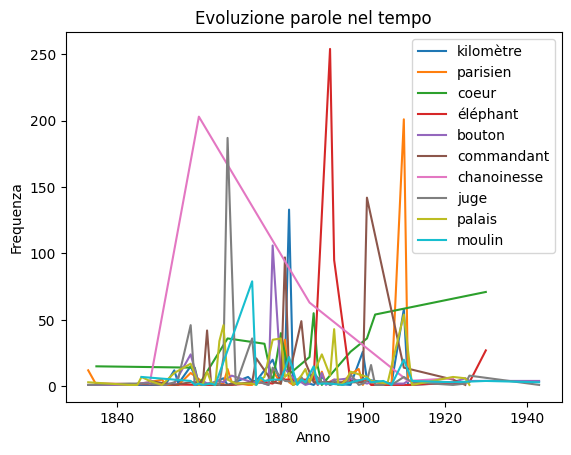

In [31]:
# plot evoluzione parole
import matplotlib.pyplot as plt

for word in list(selected_words)[:10]:  # limita per leggibilità
    subset = df_words[df_words["word"] == word]
    
    plt.plot(subset["year"], subset["count"], label=word)

plt.legend()
plt.xlabel("Anno")
plt.ylabel("Frequenza")
plt.title("Evoluzione parole nel tempo")
plt.show()

In [32]:
# distribuzione topic per anno
topic_year = df.groupby(["year", "topic"]).size().unstack(fill_value=0)

In [33]:
# forzo la visualizzazione di tutti i topic (uno non è mai predominante ma c'è)
all_topics = list(range(lda.n_components))

topic_year = (
    df.groupby(["year", "topic"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=all_topics, fill_value=0)
)

In [34]:
# normalizzazione?
topic_year_norm = topic_year.div(topic_year.sum(axis=1), axis=0)

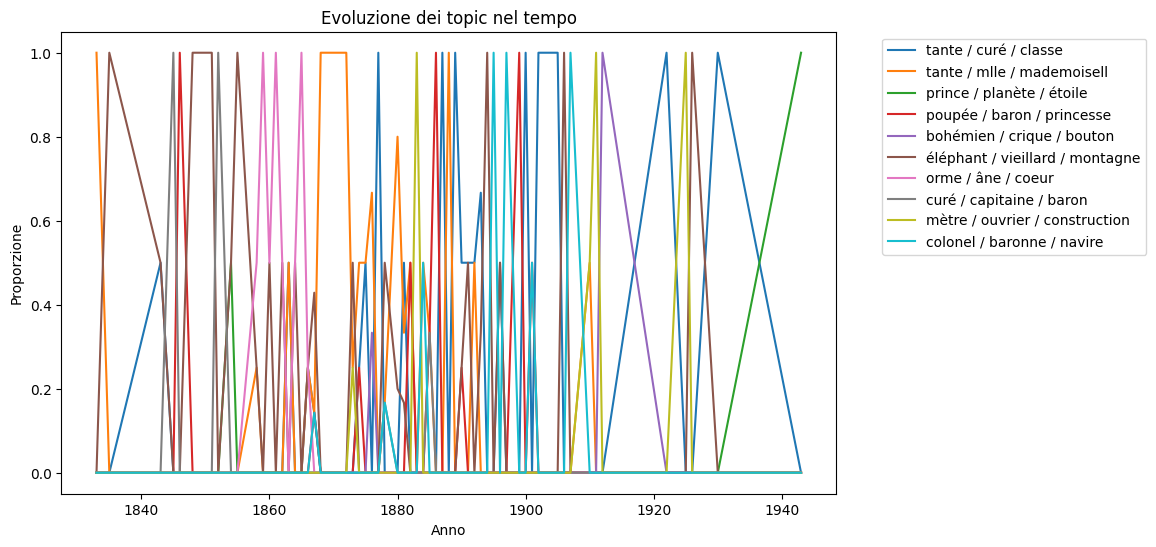

In [35]:
# plot
plt.figure(figsize=(10,6))

for topic in topic_year_norm.columns:
    plt.plot(topic_year_norm.index, topic_year_norm[topic], label=topic_labels[topic])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Anno")
plt.ylabel("Proporzione")
plt.title("Evoluzione dei topic nel tempo")
plt.show()

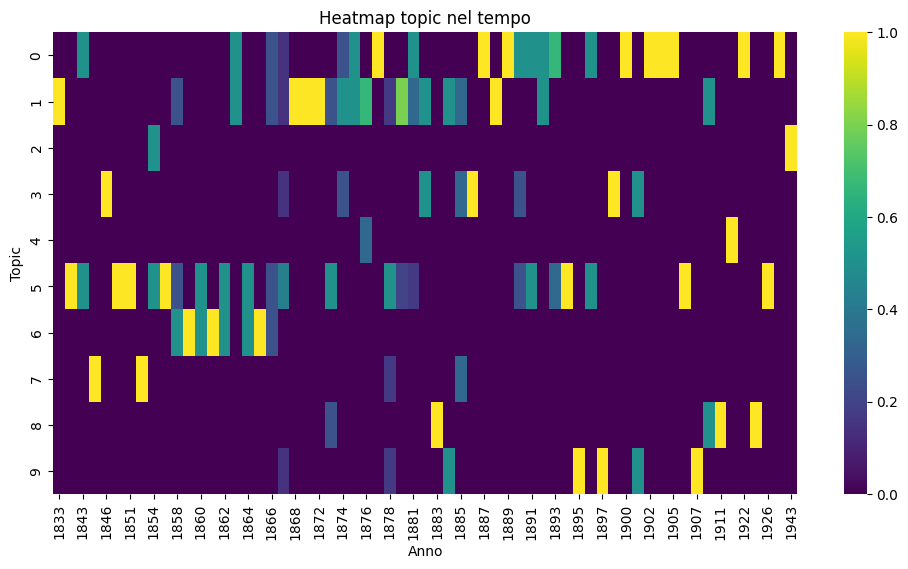

In [36]:
# heatmap
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(topic_year_norm.T, cmap="viridis")

plt.xlabel("Anno")
plt.ylabel("Topic")
plt.title("Heatmap topic nel tempo")
plt.show()

In [44]:
print(sorted(df["topic"].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
